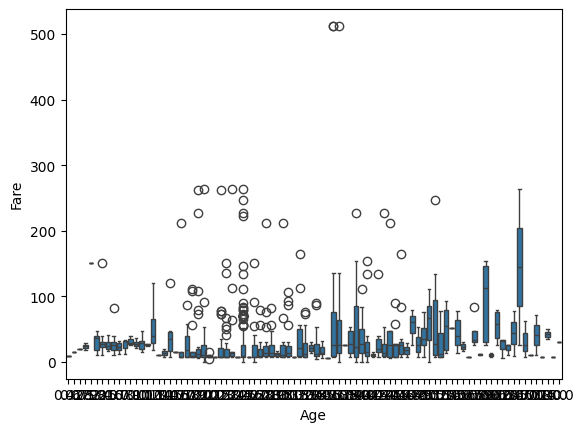

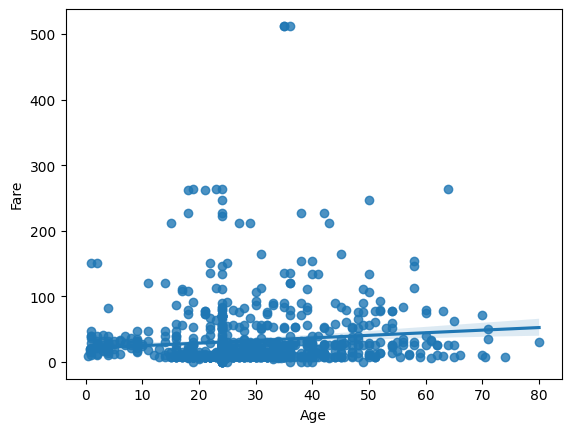

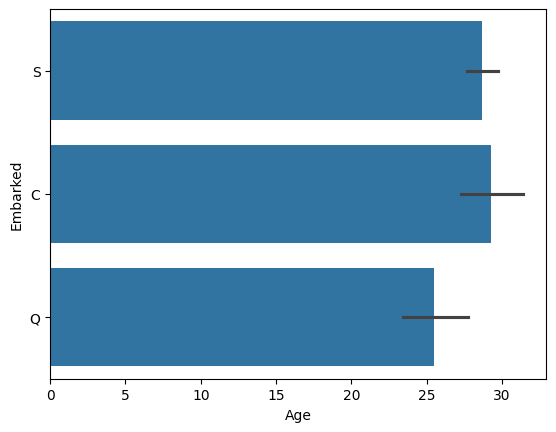

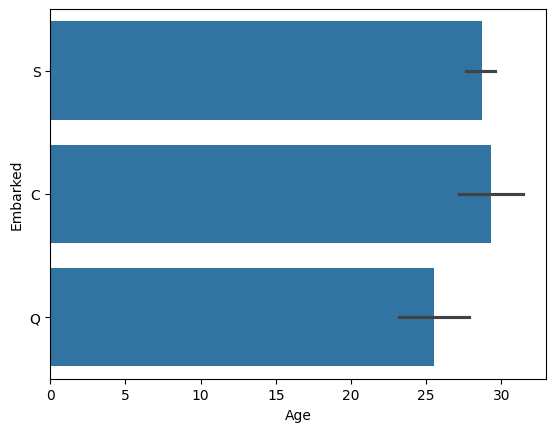

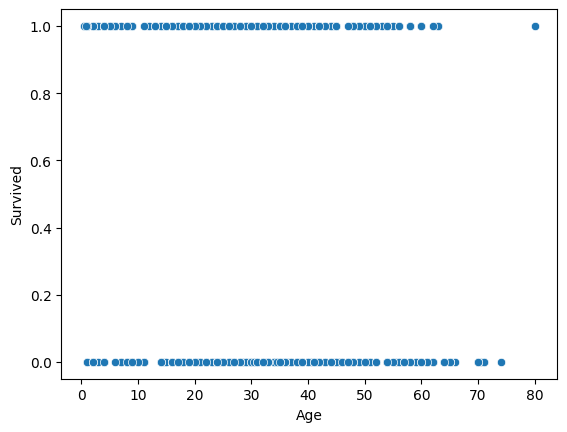

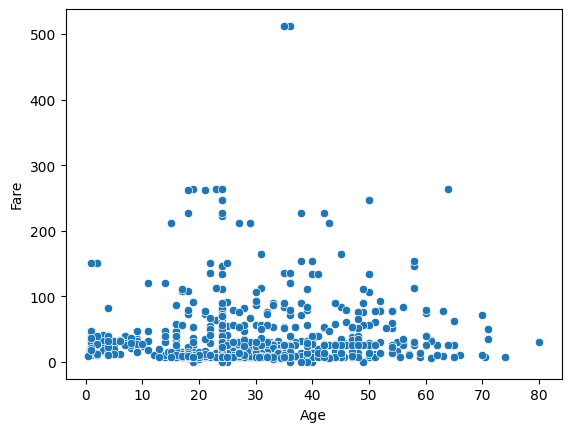

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
from tkinter import messagebox

df = pd.read_csv("titanic.csv")

df["Age"] = df["Age"].fillna(df["Age"].mode()[0])
df.drop(columns = "Cabin", inplace = True)
df.dropna(inplace = True)

plots = ["Scatterplot", "Barchart", "Boxplot", "Regression", "Heatmap"]
columns = ["PassengerId", "Survived", "Pclass", "Name", "Sex", "Age", "SibSp", "Parch", "Ticket", "Fare", "Embarked"]

def load_plot_labels(plot_type):
    for widget in axis_frame.winfo_children():
        widget.destroy()
    x_label = tk.Label(axis_frame, text="What will be on the x axis?")
    x_label.pack()
    x_entry.pack()
    y_label = tk.Label(axis_frame, text="What will be on the y axis?")
    y_label.pack()
    y_entry.pack()
    column_label = tk.Label(root, text = f"The available parameters are:\n{columns}")
    column_label.pack()
    confirm_button = tk.Button(axis_frame, text="Generate", command=lambda: x_y_plot_evaluation(plot_type))
    confirm_button.pack()

def x_y_plot_evaluation(plot_type):
    x = x_entry.get().title()
    y = y_entry.get().title()
    if x not in columns or y not in columns:
        messagebox.showerror("Invalid", "Invalid selection of parameters.")
    else:
        messagebox.showinfo("Plot successful", f"{plot_type} has been successfully generated!")
        match plot_type:
            case "Scatterplot":
                sns.scatterplot(x=x, y=y, data=df)
                plt.show()
            case "Boxplot":
                sns.boxplot(x=x, y=y, data=df)
                plt.show()
            case "Barchart":
                sns.barplot(x=x, y=y, data=df)
                plt.bar(x, y, color='steelblue')
                plt.title(f'Bar Chart of {y} against {x}')
                plt.xlabel(f'{x}')
                plt.ylabel(f'{y}')
                plt.show()
            case "Regression":
                sns.regplot(x=x, y=y, data=df)
                plt.show()
            case _:
                messagebox.showerror("Error", "Unable to generate this plot.")

def heatmap():
    messagebox.showinfo("Plot successful", "The heatmap has been generated successfully!")
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
    plt.show()

def plot_eval():
    global plot
    plot = plot_entry.get().title()
    if plot not in plots:
        messagebox.showerror("Invalid", "Invalid plot selection")
    else:
        messagebox.showinfo("Success", f"{plot} has been selected")
        plot_generation()

def plot_generation():
    if plot == "Heatmap":
        heatmap()
    else:
        load_plot_labels(plot)

root = tk.Tk()
root.title("Titanic visualization")
root.geometry("800x800")

label1 = tk.Label(root, text="Welcome to the Titanic data visualization script.")
label1.pack()
label2 = tk.Label(root, text="This is provided to help you properly visually interpret the data from the titanic incident.")
label2.pack()
label3 = tk.Label(root, text=f"\nSelect which kind of visualization you want to perform.\n{plots}")
label3.pack()

plot_entry = tk.Entry(root)
plot_entry.pack()
plot_button = tk.Button(root, text="Select plot", command=plot_eval)
plot_button.pack()

x_entry = tk.Entry(root)
y_entry = tk.Entry(root)

axis_frame = tk.Frame(root)
axis_frame.pack()

root.mainloop()

In [3]:
import seaborn as sns
help(sns.barplot)

Help on function barplot in module seaborn.categorical:

barplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    order=None,
    hue_order=None,
    estimator='mean',
    errorbar=('ci', 95),
    n_boot=1000,
    seed=None,
    units=None,
    weights=None,
    orient=None,
    color=None,
    palette=None,
    saturation=0.75,
    fill=True,
    hue_norm=None,
    width=0.8,
    dodge='auto',
    gap=0,
    log_scale=None,
    native_scale=False,
    formatter=None,
    legend='auto',
    capsize=0,
    err_kws=None,
    ci=<deprecated>,
    errcolor=<deprecated>,
    errwidth=<deprecated>,
    ax=None,
    **kwargs
)
    Show point estimates and errors as rectangular bars.

    A bar plot represents an aggregate or statistical estimate for a numeric
    variable with the height of each rectangle and indicates the uncertainty
    around that estimate using an error bar. Bar plots include 0 in the
    axis range, and they are a good choice when 0 is a meaningful value
